In [ ]:
import shutil
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import PIL
from PIL import Image
from fastai.vision.all import untar_data, URLs

Using device: cpu


# FastAI imports + Loading in the Data

The data is a small sample of the COCO dataset for object detection and is loaded in through the external data functionality of fastai. The actual paper uses the entire ImageNet dataset while we only use 8000 training images.

In [11]:
from urllib.error import URLError
import ssl

project_root = Path.cwd()
coco_root = project_root / "mlops-coco"
coco_images_path = coco_root / "images"

def _download_coco_sample(dest_root: Path) -> Path:
    """Download COCO sample with compatibility across fastai versions and SSL fallback."""
    def _run_download() -> Path:
        try:
            return untar_data(URLs.COCO_SAMPLE, dest=dest_root)
        except TypeError:
            # Older fastai versions do not support the dest argument.
            return untar_data(URLs.COCO_SAMPLE)

    try:
        return _run_download()
    except URLError as e:
        if "CERTIFICATE_VERIFY_FAILED" not in str(e):
            raise
        print("SSL certificate verification failed. Retrying once without SSL verification...")
        original_https_context = ssl._create_default_https_context
        try:
            ssl._create_default_https_context = ssl._create_unverified_context
            return _run_download()
        finally:
            ssl._create_default_https_context = original_https_context

if coco_images_path.exists() and any(coco_images_path.glob("*.jpg")):
    path = coco_images_path
    data_status = f"Loaded cached dataset from {path}"
else:
    try:
        downloaded_path = _download_coco_sample(project_root)
        downloaded_path = Path(downloaded_path)

        if downloaded_path != coco_images_path and not coco_images_path.exists():
            shutil.move(str(downloaded_path), str(coco_images_path))
            path = coco_images_path
        else:
            path = downloaded_path
        data_status = f"Downloaded dataset to {path}"
    except URLError as e:
        raise RuntimeError(
            "Could not download COCO sample due to SSL certificate verification. "
            "Use the local dataset in mlops-coco/images or install/update certificates in your Python environment."
        ) from e

print(data_status)
paths = glob.glob(str(path / "*.jpg"))
print(f"Found {len(paths)} images")

Loaded cached dataset from /workspace/mlops-coco/images
Found 21837 images


In [15]:
from pathlib import Path
import shutil

src_dir = Path("/workspace/mlops-coco/images/train_sample")
dst_dir = Path("/workspace/mlops-coco/images")

jpg_files = list(src_dir.glob("*.jpg"))
for src_path in jpg_files:
    shutil.move(str(src_path), str(dst_dir / src_path.name))

print(f"Moved {len(jpg_files)} .jpg file(s) from {src_dir} to {dst_dir}")

Moved 0 .jpg file(s) from /workspace/mlops-coco/images/train_sample to /workspace/mlops-coco/images


# Filtering out grayscale images

In [16]:
def is_grayscale(image_or_path, tol=2, sample_size=8):
    """
    Returns True if image is grayscale-like.
    tol: max allowed channel difference in [0,255].
    sample_size: image is downsampled to sample_size x sample_size for speed.
    """
    if isinstance(image_or_path, (str, Path)):
        img = Image.open(image_or_path)
    elif isinstance(image_or_path, PIL.Image.Image):
        img = image_or_path
    else:
        raise ValueError("Input must be a file path or PIL Image.")
    # Fast-path for already grayscale modes
    if img.mode in ("1", "L", "LA"):
        return True
    # Convert to RGB and optionally downsample for faster processing
    img = img.convert("RGB")
    if sample_size is not None:
        img = img.resize((sample_size, sample_size), Image.BILINEAR)
    # Check max channel differences
    arr = np.asarray(img, dtype=np.int16)
    rg_max = np.abs(arr[:, :, 0] - arr[:, :, 1]).max()
    gb_max = np.abs(arr[:, :, 1] - arr[:, :, 2]).max()
    # If both max differences are below the tolerance, it's grayscale-like
    return (rg_max <= tol) and (gb_max <= tol)

def filter_grayscale_paths(paths_array):
    """Return filtered paths and grayscale subset for a given split."""
    paths_np = np.asarray(paths_array, dtype=object)
    gray_mask = np.fromiter(
        (is_grayscale(p) for p in tqdm(paths_np, total=len(paths_np), desc="Checking grayscale")),
        dtype=bool,
        count=len(paths_np))
    grayscale_paths = paths_np[gray_mask]
    filtered_paths = paths_np[~gray_mask].tolist()
    return filtered_paths, grayscale_paths

def visualize_imgs(image_paths, title=None):
    if len(image_paths) == 0:
        return
    fig, axes = plt.subplots(1, len(image_paths), figsize=(10, 4))
    if title:
        fig.suptitle(title, fontsize=16)
    if len(image_paths) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, image_paths):
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
    plt.show()

In [17]:
def test_is_grayscale(img_path:str, expected:bool):
    try:
        with Image.open(img_path) as img:
            assert is_grayscale(img) == expected
    except (FileNotFoundError, OSError, AssertionError) as e:
        print(f"{img_path}: {e}")

test_is_grayscale(path / "000000000328.jpg", True)
test_is_grayscale(path / "000000000599.jpg", False)

Checking grayscale: 100%|█████████▉| 21836/21837 [02:04<00:00, 176.05it/s]


Grayscale images found: 371


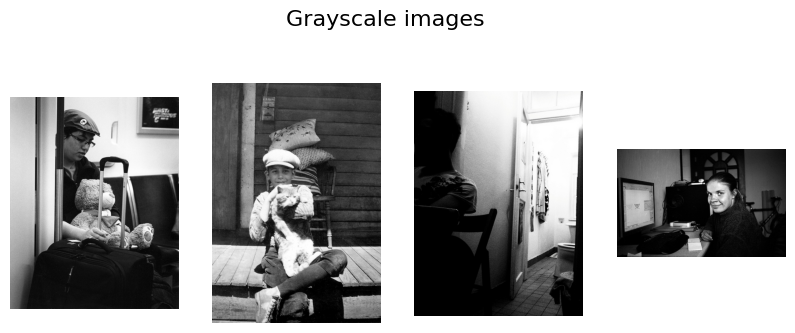

Removed 371 files.


In [18]:
# Filtering grayscale images
filtered_paths, grayscale_paths = filter_grayscale_paths(paths)
print(f"Grayscale images found: {len(grayscale_paths)}")
visualize_imgs(grayscale_paths[:min(4, len(grayscale_paths))].tolist(), title="Grayscale images")

# Update main paths without grayscale images
paths = filtered_paths

# Remove grayscale files from disk
removed_count = 0
failed_count = 0
for p in set(grayscale_paths.tolist()):
    p = Path(p)
    try:
        if p.exists():
            p.unlink()
            removed_count += 1
    except OSError as e:
        failed_count += 1
        print(f"Failed to delete {p}: {e}")

print(f"Removed {removed_count} files.")
if failed_count:
    print(f"Failed to remove {failed_count} files.")